In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tarfile
import urllib.request
from pathlib import Path

from sklearn import set_config
set_config(display="diagram")

# Case Study
* **Aim**: To predict the median housing price in any district (given all the other metrics) by building a model using California census data.

## 1. Look at the big picture and frame the problem

1) Determine the business objective.
<br>

2) Review the current solution (if any), which will give us a reference for performance, as well as insights on how to solve the problem.
<br>

3) Deterimine which model to use.
    - Supervised ML: data were labeled
    - Regression task: to predict a value
        - Multiple regression: use multiple features 
        - Univariate regression: predict a single value
<br>

4) Select a performance measure
    - **Root mean squared error (RMSE)**: generally the preferred performance measure for regression problems
    <br>
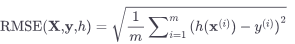
    - **Mean absolute error (MAE)**: more robust to outliers
    <br>
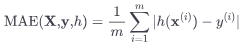
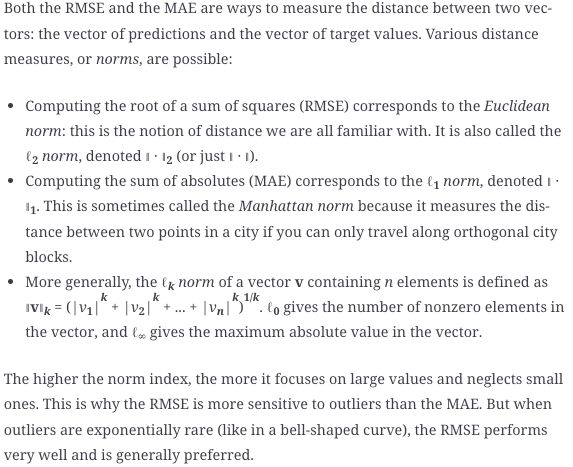
<br>

5) Check the assumptions
    - If downstream pipeline requires categorical variable input, we need to use classifcation model.

*Data pipeline: a sequence of data processing components.*

## 2. Get the Data
### 2.1 Take a Quick Look at the Data Structure

In [2]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [6]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
print(housing_full.head(6))
print(housing_full.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [5]:
# For numeric variables
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [18]:
# For categorical variables
housing_full['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

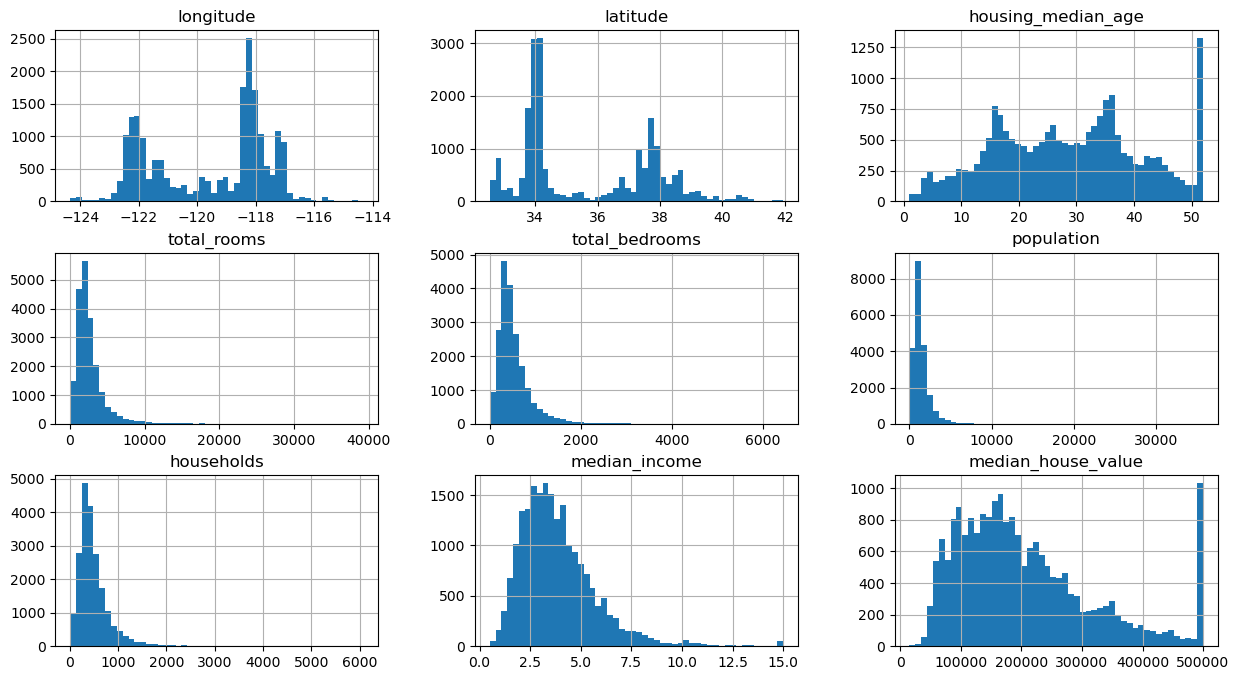

In [7]:
housing_full.hist(bins=50, figsize = (15, 8))
plt.show()
# plt.close('all') # Close all open figures to avoid memory issues when running this cell multiple times.

From the histogram, we can see that the `housing_median_age` and `median_house_value` were capped. The latter may be a problem since it is our target attribute. We need to check with the client team. If they need precise predictions even beyond 500,000, we can
- Collect proper labels for the districts whose labels were capped
- Remove those districts from the training and test set.

### 2.2 Create a Test Set
We need to create a test set, put it aside (never look at it), before look at the data any further. This is to avoid ***data snooping bias***, as the generalization error estimated from the test set can be underestimated if we select the ML model based on the test data. Typically, the test set comprises 20% of the data.

`np.random.default_rng(seed = x)` is Okay, but it will break the next time the dataset has been updated (e.g., more observations). To have a stable train/test split even after updating the dataset, a common solution is to use each instance's identifier to decide whether it should go in the test set (assuming instances have unique and immutable identifiers).

`CRC32` is a hashing algorithm that converts any input into a fixed 32-bit integer. Key properties
- Deterministic: same input -> always same output
- Stable: does not change across Python sessions
- Pesudo-random distribution: outputs are spread uniformly across the range

In [8]:
from zlib import crc32

def train_test_set(df, train_ratio):
    df_index = df.reset_index()
    in_train_set = df_index['index'].apply(lambda id_: crc32(str(id_).encode('utf-8')) <= train_ratio * 2**32)
    return df.loc[in_train_set], df.loc[~in_train_set]

train_set, test_set = train_test_set(housing_full, 0.8)

In [21]:
print(train_set.shape)
print(test_set.shape)

(16495, 10)
(4145, 10)


Alternatively, `Scikit-Learn` provides a few functions to split datasets, such as `train_test_split()`, which suffers the same problems as `np.random.default_rng(seed = x)`

In [22]:
from sklearn.model_selection import train_test_split
train_set_rd2, test_set_rd2 = train_test_split(housing_full, test_size = 0.2, random_state = 316)

`train_test_split()` function also allows us to perform stratified sampling.

In [24]:
housing_full['income_cat'] = pd.cut(housing_full['median_income'], 
                                    bins = [0., 1.5, 3., 4.5, 6., np.inf],
                                    labels = [1, 2, 3, 4, 5])

train_set_str, test_set_str = train_test_split(housing_full, test_size = 0.2, random_state = 316, 
                                               stratify = housing_full['income_cat'])

## 3. Explore and Visualize the Data to Gain Insights

If the training set is very large, we may sample an exploration set, to make data manipulations easy and fast. 
<br>
We should make copy of the original since we will experiment with various transformations of the training set.

In [9]:
housing = train_set.copy()

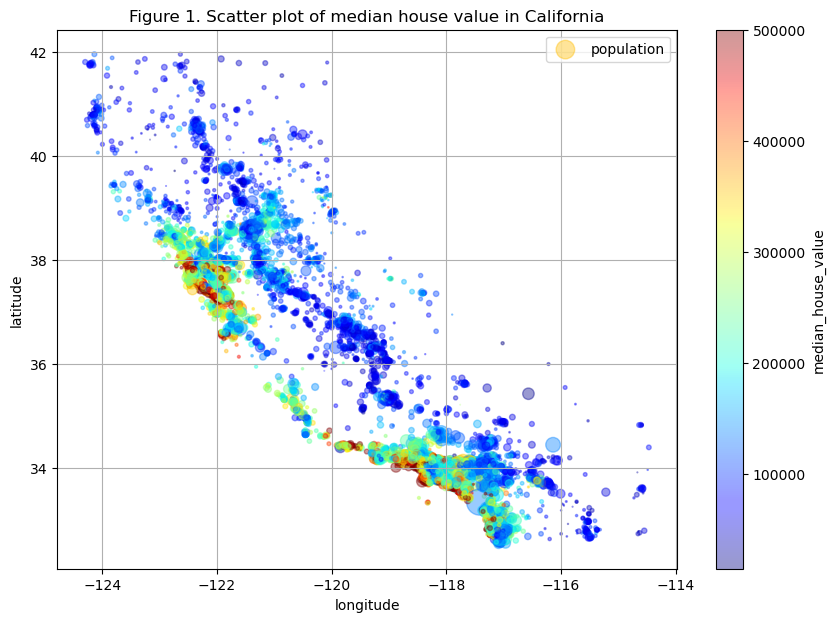

In [11]:
plt.close('all')
housing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', alpha = 0.4, 
             s = housing['population']/100, label = 'population', 
             c = 'median_house_value', cmap = plt.get_cmap('jet'), colorbar = True,
             grid = True, figsize = (10, 7), 
             title = 'Figure 1. Scatter plot of median house value in California')
plt.show()

From the figure, we can see that median housing prices are positively related to proximity to the ocean.

In [27]:
housing.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924959,-0.107683,0.042247,0.070219,0.102844,0.054853,-0.018081,-0.045199
latitude,-0.924959,1.000000,0.013379,-0.033984,-0.067226,-0.111186,-0.070826,-0.076912,-0.144878
housing_median_age,-0.107683,0.013379,1.000000,-0.362685,-0.322605,-0.297254,-0.304803,-0.119282,0.107178
total_rooms,0.042247,-0.033984,-0.362685,1.000000,0.928445,0.850365,0.914929,0.199505,0.136508
total_bedrooms,0.070219,-0.067226,-0.322605,0.928445,1.000000,0.872316,0.978069,-0.009083,0.050578
population,0.102844,-0.111186,-0.297254,0.850365,0.872316,1.000000,0.903748,0.003611,-0.024502
households,0.054853,-0.070826,-0.304803,0.914929,0.978069,0.903748,1.000000,0.011601,0.067497
median_income,-0.018081,-0.076912,-0.119282,0.199505,-0.009083,0.003611,0.011601,1.000000,0.685949
median_house_value,-0.045199,-0.144878,0.107178,0.136508,0.050578,-0.024502,0.067497,0.685949,1.000000


In [28]:
housing.corr(numeric_only=True)['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.685949
total_rooms           0.136508
housing_median_age    0.107178
households            0.067497
total_bedrooms        0.050578
population           -0.024502
longitude            -0.045199
latitude             -0.144878
Name: median_house_value, dtype: float64

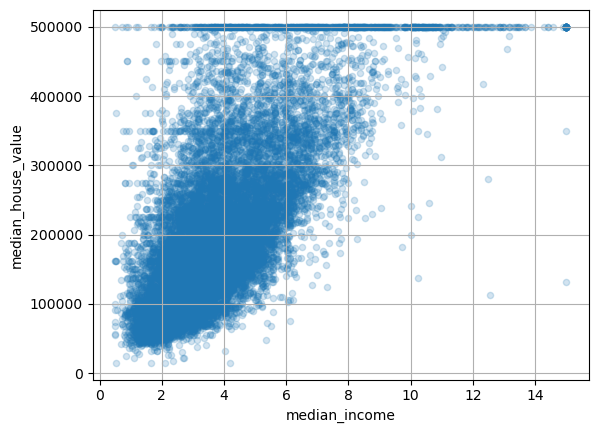

In [29]:
housing.plot(kind = 'scatter', x = 'median_income', y = 'median_house_value', 
             alpha = 0.2, grid=True)
plt.show()

Of note, the correlation coefficient only measures **linear** correlations.\
<br>

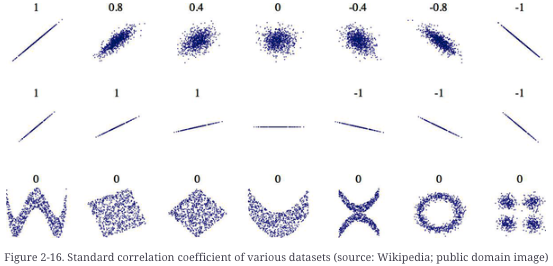

Additionally, we may want to try out various attribute combinations. For example, the total number of rooms in a district is not very useful if we don't know how many households are there. After excecuting the code below, we found that `bedrooms_ratio` attribute is much more correlated with the median house value than the `total_rooms` or `total_bedrooms`.

In [30]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]
housing.corr(numeric_only=True)['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.685949
rooms_per_house       0.150393
total_rooms           0.136508
housing_median_age    0.107178
households            0.067497
total_bedrooms        0.050578
people_per_house     -0.022459
population           -0.024502
longitude            -0.045199
latitude             -0.144878
bedrooms_ratio       -0.256796
Name: median_house_value, dtype: float64

## 4. Prepare the Data for ML Algorithms

Instead of doing this manually, we should write functions, so that our pipeline is reproducible and less error-prone. Let's create a function to add the combined attributes:, portable, and easy to experiment with.

In [12]:
housing = train_set.drop(columns=['median_house_value']).copy()
housing_labels = train_set['median_house_value'].copy()

### 4.1. Clean the Data

Missing data: `dropna()`, `fillna()`, `SimpleImputer` from Scikit-Learn

In [31]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')

The `imputer` has simply computed the median of each attribute and stored the result in its statistics_ instance variable.

In [32]:
housing_num = housing.select_dtypes(include = 'number')
imputer.fit(housing_num) # Estimator

SimpleImputer(strategy='median')

In [33]:
print(imputer.feature_names_in_)
print(imputer.strategy)
print(imputer.statistics_)
print(housing_num.median())

['longitude' 'latitude' 'housing_median_age' 'total_rooms'
 'total_bedrooms' 'population' 'households' 'median_income']
median
[-118.49     34.25     29.     2123.      434.     1167.      409.
    3.5398]
longitude             -118.4900
latitude                34.2500
housing_median_age      29.0000
total_rooms           2123.0000
total_bedrooms         434.0000
population            1167.0000
households             409.0000
median_income            3.5398
dtype: float64


In [34]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns = housing_num.columns, index = housing_num.index)

**Scikit-Learn's API** is remarkably well designed.
- Consistency (all objects share a consistent and simple interface)
    - ***Estimators***: Any object that can estimate some parameters based on a dataset is called an estimator (e.g., `SimpleImputer`). The estimation is performed by the **`fit()`** method, which takes a dataset as a parameter, or two for supervised learning (the second dataset contains the label). Any other parameter needed to guide the estimation process is considered a **hyperparamter** (such as a `SimpleImputer`'s `strategy`), and it must be set as an instance variable (generally via a constructor parameter)
    - ***Transformers***: are estimators which can also transforms a dataset (e.g., `SimpleImputer`). The transformation is performed by the **`transform()`** method with the dataset to transform as a parameter, it returns the transformed dataset. 
        - All transformers also have a convenience method called **`fit_transform()`**, which is equivalent to calling `fit()` and then `transform()`. Sometimes `fit_transform()` is optimized and runs much faster.
    - ***Predictors***: are estimators that can make predictions given a dataset. (e.g., `LinearRegression` model)
    - 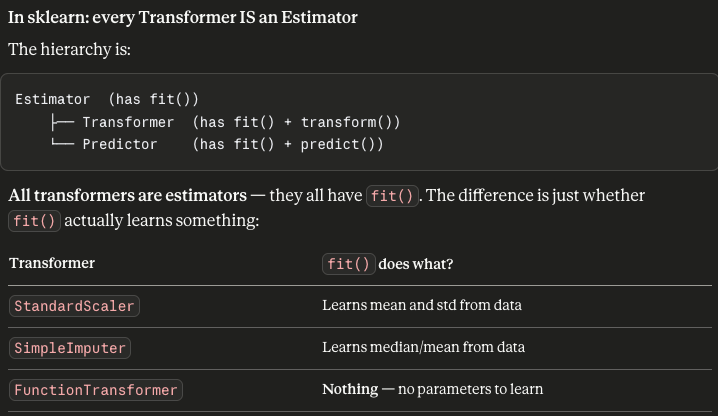

- Inspection
    - All estimators' **hyperparameters** are accessible via public instance variables (e.g., `imputer.strategy`)
    - All estimators' **learned parameters** are accessible via public instance variables with an **underscore suffix** (e.g., `imputer.statistics_`)
    - The estimators always store the column names in the `feature_names_in` attribute.

- Nonproliferation of classes: Datasets are represented as NumPy arrays or SciPy sparse matrices, instead of homemade classes. Hyperparameters are just regular Python strings or numbers.

- Composition: Existing building blocks are reused as much as possible. For example, it is easy to create a `Pipeline` estimator from an arbitrary sequence of transformers followed by a final estimator.

- Sensible defaults: Scikit-Learn provides reasonable default values for most parameters, making it easy to quickly create a baseline working system.

### 4.2. Handling Text and Categorical Attributes

Most ML algorithms prefer to work with numbers, so we need to convert categorical variables to numbers by using the **one-hot encoding** (because only one attribute will be equal to 1 (hot) while the others will be 0 (cold)). The new attributes are sometimes called **dummy attributes**.

In [35]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7371
INLAND        5177
NEAR OCEAN    2111
NEAR BAY      1831
ISLAND           5
Name: count, dtype: int64

In [36]:
housing_cat = housing.select_dtypes(include = 'object').copy()

In [37]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder()
housing_cat_1hot = one_hot_encoder.fit_transform(housing_cat)

The output of `OneHotEncoder` is a SciPy **sparse matrix** instead of NumPy array. A sparse matrix is a very efficient representation for matrices that contain mostly zeros. Indeed, internally it only stores the nonzero values and their positions.

In [38]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16495 stored elements and shape (16495, 5)>

In [39]:
print(housing_cat_1hot.toarray())
print(housing_cat_1hot.toarray().shape)

[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
(16495, 5)


In [40]:
print(one_hot_encoder.feature_names_in_)
print(one_hot_encoder.get_feature_names_out())
print(one_hot_encoder.categories_)

['ocean_proximity']
['ocean_proximity_<1H OCEAN' 'ocean_proximity_INLAND'
 'ocean_proximity_ISLAND' 'ocean_proximity_NEAR BAY'
 'ocean_proximity_NEAR OCEAN']
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [41]:
housing_cat_dummy = pd.DataFrame(housing_cat_1hot.toarray(), 
                                 columns = one_hot_encoder.get_feature_names_out(),
                                 index = housing_cat.index)
housing_cat_dummy.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,1.0,0.0


### 4.3. Feature Scaling and Transformation

ML Algorithms don't perform well when the input numerical attributes have very different scales, so we need to apply ***feature scaling***.
- ***Min-max scaling***: rescaled ranging from 0 to 1 through subtracting the min value from all values, and dividing the results by the difference between the min and the max.
- ***Standardization***: subtracts the mean value then divided by SD (mean 0, SD 1). 
- Compared to min-max scaling, standardization is much less affected by outliers.

In [42]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(0, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [43]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
housing_num_standard_scaled = standard_scaler.fit_transform(housing_num)

When a feature's distribution has a heavy tail, both min-max scaling and standardization will squash most values into a small range, in which ML models generally don't like this at all. 
- In such cases, it is often a good idea to first apply a transformation to shrink the heavy tail (e.g, log-transformation or square root transformation), which will make the distribution more Gaussian-like, and then apply min-max scaling or standardization.
- Another approach is bucketizing the feature (i.e., categorization). E.g., categorization into quartiles/quintile. `pd.qcut()`. Then either assign numeric values to each category or use `OneHotEncoder`.
<br>

For variables with multimodal distributions (with >= 2 clear modes), we can either
- Categorize the variable and then use `OneHotEncoder`
- Add a feature for each of the modes (at least the main ones), representing the similarity between the attribute (e.g., housing median age) and that particular mode (e.g., 35). This similarity measure is typically computed using a ***Gaussian radial basis function (RBF)*** (function that depends only on the distance between the input value and a fixed point).
<br>

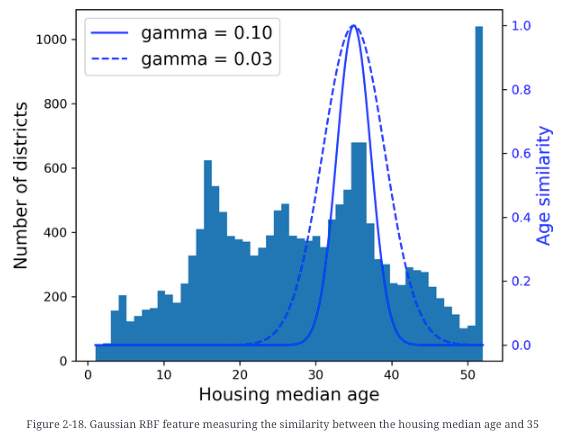

In [18]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma = 0.1)

The target value may also need to be transformed before putting into the model, and transformed back afterward. `TransformedTargetRegressor` will automatically use the transformer to scale the labels and train the regression model on the resulting scaled labels. Then, when we want to make a prediction, it will call the regression model’s `predict()` method and use the scaler’s `inverse_transform()` method to produce the prediction.

In [46]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression

model = TransformedTargetRegressor(LinearRegression(), transformer = StandardScaler())
model.fit(housing[['median_income']], housing_labels)

some_new_data = housing[['median_income']].iloc[:5, :]  # pretend this is new data
model.predict(some_new_data)

array([392534.03368449, 348863.35998779, 281336.95333206, 214145.18785409,
       198345.94124945])

### 4.4. Custom Transformers

In [47]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func = np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [48]:
rbk_transformer = FunctionTransformer(rbf_kernel, kw_args = {"Y": [[35]], "gamma": 0.1})
age_simil_35_v2 = rbk_transformer.transform(housing[["housing_median_age"]])

`FunctionTransformer` is handy, but it does **NOT** allow your transformer to learn parameters in the `fit()` method and use them later in the `transform()` method. For this, we need to write a custom class. All they need is three methods: `fit()`(which must return `self`), `transform()`, and `fit_transform()`.
- By adding `TransformerMixin` we can get `fit_transform()` for free.
- By adding `BaseEstimator`, we can get two extra methods: `get_params()` and `set_params()`, which will be useful for automatic hyperparameter tuning.

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit()
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.values
        return self  # must return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_in_
        else:
            return input_features

A custom transformer can and often use other estimator in its implementation.

In [26]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"cluster_{i}_similarity" for i in range(self.n_clusters)]

In [27]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=316)
similarities = pd.DataFrame(cluster_simil.fit_transform(housing[["latitude", "longitude"]]), 
                            index=housing.index, 
                            columns=cluster_simil.get_feature_names_out())
similarities.head().round(2)

,cluster_0_similarity,cluster_1_similarity,cluster_2_similarity,cluster_3_similarity,cluster_4_similarity,cluster_5_similarity,cluster_6_similarity,cluster_7_similarity,cluster_8_similarity,cluster_9_similarity
1,0.0,0.98,0.0,0.0,0.0,0.14,0.0,0.22,0.62,0.0
2,0.0,0.98,0.0,0.0,0.0,0.13,0.0,0.21,0.62,0.0
3,0.0,0.99,0.0,0.0,0.0,0.13,0.0,0.20,0.62,0.0
5,0.0,0.99,0.0,0.0,0.0,0.13,0.0,0.20,0.62,0.0
6,0.0,0.98,0.0,0.0,0.0,0.12,0.0,0.20,0.63,0.0


### 4.5. Transformation Pipelines

The estimators within the pipeline must all be transformers, except for the last one, which can be anything: a transformer, a predictor, or any other type of estimator.

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attributes = housing.select_dtypes(include = 'number').columns.to_list()
cat_attributes = housing.select_dtypes(include = 'object').columns.to_list()

num_pipeline = Pipeline([
    ('median_impute', SimpleImputer(strategy = 'median')),
    ('standardize', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encode', OneHotEncoder())
])

preprocessing = ColumnTransformer(
    [
        ("num_preprocessing", num_pipeline, num_attributes),
        ("cat_preprocessing", cat_pipeline, cat_attributes),
    ], 
    remainder = 'drop')

housing_prepared = pd.DataFrame(preprocessing.fit_transform(housing),
                                columns = preprocessing.get_feature_names_out(),
                                index = housing.index)

In `ColumnTransformer()`, instead of using a transformer, we can specify 
- `'drop'` (as the 2nd parameter of the tuple) if we want the columns to be dropped
- `'passthrough'` (as the 2nd parameter of the tuple) if we want the columns to be left untouched.
- It is recommended to set the `remainder` ***hyperparameter*** to explicitly show how to handle the remaining columns (though by default, the untouched columns would be dropped).

Pipelines support indexing

In [48]:
print(num_pipeline['median_impute'])
print(num_pipeline[1])

SimpleImputer(strategy='median')
StandardScaler()


Recap the entire pipeline:
- **Missing data**: numerical features (median imputation), categorical (missing category)
- **New feature generation**: generate new features that better correlate with the outcome -> help the ML models
- **Categorical variables**: one-hot encoded
- **Numerical variables**: 
    - if it has skewed distribution, perform transformation to make its distribution roughly normal distribution
    - otherwise, perform standardization, as most ML algorithms prefer when all features have ~ the samescale.

Convenient function pairs:
- `Pipeline()` -> `make_pipeline()`
- `ColumnTransformer()` -> `make_column_transformer()` & `make_column_selector()`

In [49]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(column_ratio, feature_names_out=ratio_name),
    StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

cat_pipeline = Pipeline([
    ('one_hot_encode', OneHotEncoder())
])

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler())

preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline, ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline, ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline, ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [ ]:
housing_prepared = pd.DataFrame(preprocessing.fit_transform(housing), 
                                columns=preprocessing.get_feature_names_out(),
                                index=housing.index)
housing_prepared.head()

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
1,-0.897465,0.344632,-0.085516,1.325977,1.669615,1.039733,1.456816,1.856478,5.707989e-23,0.312103,...,0.000518,0.032207,1.496279e-07,0.982400,0.0,0.0,0.0,1.0,0.0,-0.605871
2,-1.303881,1.211973,-0.025871,-1.114980,-0.454715,-1.119969,-1.111084,1.570085,5.085732e-23,0.297357,...,0.000479,0.029952,1.452904e-07,0.984415,0.0,0.0,0.0,1.0,0.0,1.856215
3,-0.454223,0.166600,-0.047778,-0.820425,-0.644762,-0.958672,-0.817265,1.033984,4.573259e-23,0.291226,...,0.000455,0.029325,1.386130e-07,0.985988,0.0,0.0,0.0,1.0,0.0,1.856215
5,0.277485,-0.280057,-0.082927,-0.956634,-1.084830,-1.370753,-0.991664,0.320183,4.573259e-23,0.291226,...,0.000455,0.029325,1.386130e-07,0.985988,0.0,0.0,0.0,1.0,0.0,1.856215
6,-0.323687,-0.208026,-0.083917,0.195014,0.282222,-0.036711,0.360034,0.110858,5.035052e-23,0.289040,...,0.000466,0.028427,1.477567e-07,0.984072,0.0,0.0,0.0,1.0,0.0,1.856215


## 5. Select and Train a Model

First, try fitting linear regression model.

In [56]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

print(f'first 6 predictions: {lin_reg.predict(housing)[:6].round(-3)}')
print(f'first 6 actual values: {housing_labels.iloc[:6].values}')


first 6 predictions: [373000. 358000. 319000. 290000. 283000. 280000.]
first 6 actual values: [358500. 352100. 341300. 269700. 299200. 241400.]


In [57]:
from sklearn.metrics import root_mean_squared_error
lin_rsme = root_mean_squared_error(housing_labels, lin_reg.predict(housing))
print(f'RSME: {lin_rsme:.2f}')

RSME: 69636.52


Try decision tree regression. The results clearly indicated overfitting problems.

In [58]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=316))
tree_reg.fit(housing, housing_labels)

tree_reg_rmse = root_mean_squared_error(housing_labels, tree_reg.predict(housing))
print(f'RSME: {tree_reg_rmse:.2f}')

RSME: 0.00


Using cross-validation to evaluate the performance of decision tree, it seems to perform almost as poorly as the linear regression model.

In [59]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

print(pd.Series(tree_rmses).describe())

count       10.000000
mean     67765.256650
std       2901.891046
min      63491.235514
25%      66442.156298
50%      67161.480979
75%      69300.620673
max      73714.827522
dtype: float64


We then try random forest model, which performed much better in CV. However, before we dive much deeper into random forests, **we should try out many other models from various categories of ML algorithms** (e.g., SVM, NN), without spending too much time tweaking the hyperparameters. **The goal is to shortlist a few (two to five) promising models.**

In [60]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=316))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

print(pd.Series(forest_rmses).describe())

count       10.000000
mean     47397.490094
std       1867.317729
min      44768.057737
25%      46330.528287
50%      47700.425715
75%      48171.977141
max      51156.308144
dtype: float64


## 6. Fine-Tune Your Model

Assume we have a shortlist of promising models. We now need to fine-tune them.

### 6.1. Grid Search

In [61]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=316)),
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x16bfa6e40>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=316))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [66]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,10.471083,0.058815,0.202498,0.003036,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-45829.690258,-42902.127885,-42445.208601,-43725.675581,1499.411468,1
13,13.482934,0.186372,0.221445,0.021759,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-46253.987344,-43606.778476,-42707.047577,-44189.271133,1505.471953,2
6,7.867874,0.072036,0.276910,0.043803,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-46697.420496,-43467.025350,-43189.224181,-44451.223342,1592.345150,3
9,12.352058,0.208247,0.245654,0.004298,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-46568.419908,-44225.499129,-43121.202572,-44638.373870,1437.283550,4
7,11.655723,0.081792,0.242912,0.015822,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-46568.419908,-44225.499129,-43121.202572,-44638.373870,1437.283550,4


### 6.2. Randomized Search

The grid search approach is fine when you are exploring relatively few combinations, while `RandomizedSearchCV` is often preferrable, especially when the hyperparameter search space is large. It has several benefits:
- If some parameters are continuous (or have many possible values).
- If a hyperparameter does not make much different but we don't know it yet.
- If the number of hyperparameter is large.

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=316)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x16bfa6e40>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=316))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16b3a6120>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16bfc2490>},
                   random_state=316, scoring='neg_root_mean_squared_error')

In [68]:
rnd_res = pd.DataFrame(rnd_search.cv_results_)
rnd_res.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
7,15.947005,0.243510,0.212580,0.009189,42,9,"{'preprocessing__geo__n_clusters': 42, 'random...",-44669.768882,-41730.587759,-40851.755973,-42417.370871,1632.596894,1
1,8.978443,1.078499,0.190949,0.026817,27,6,"{'preprocessing__geo__n_clusters': 27, 'random...",-45000.224282,-41598.819224,-41194.355959,-42597.799822,1706.776709,2
9,12.049937,0.006868,0.202640,0.001124,27,7,"{'preprocessing__geo__n_clusters': 27, 'random...",-44811.273614,-42037.882516,-41298.042236,-42715.732789,1512.241035,3
3,24.124406,0.208665,0.242561,0.028509,32,13,"{'preprocessing__geo__n_clusters': 32, 'random...",-45333.230524,-42662.164662,-41712.506605,-43235.967264,1532.829082,4
5,16.940442,0.339383,0.247237,0.012547,20,8,"{'preprocessing__geo__n_clusters': 20, 'random...",-45566.113956,-42748.741102,-42214.000424,-43509.618494,1470.457318,5


### 6.3. Analyzing the Best Models and Their Errors

In [72]:
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.2 , 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.02, 0.01, 0.01, 0.02, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.  , 0.01, 0.01, 0.01, 0.02,
       0.02, 0.04, 0.01, 0.01, 0.01, 0.02, 0.  , 0.09, 0.  , 0.  , 0.  ,
       0.01])

In [73]:
sorted(zip(feature_importances, final_model["preprocessing"].get_feature_names_out()), reverse=True)

[(np.float64(0.2004363197420586), 'log__median_income'),
 (np.float64(0.08676049338520576), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06345313141586462), 'bedrooms__ratio'),
 (np.float64(0.05038906579019439), 'rooms_per_house__ratio'),
 (np.float64(0.04940102744636671), 'people_per_house__ratio'),
 (np.float64(0.035832318738924916), 'geo__Cluster 37 similarity'),
 (np.float64(0.02419533600488005), 'geo__Cluster 29 similarity'),
 (np.float64(0.02318580257023709), 'geo__Cluster 20 similarity'),
 (np.float64(0.021731610563517367), 'geo__Cluster 41 similarity'),
 (np.float64(0.020480732740409246), 'geo__Cluster 36 similarity'),
 (np.float64(0.017356747736404107), 'geo__Cluster 24 similarity'),
 (np.float64(0.01735072317349051), 'geo__Cluster 23 similarity'),
 (np.float64(0.015255158992378974), 'geo__Cluster 35 similarity'),
 (np.float64(0.015110876643420786), 'geo__Cluster 30 similarity'),
 (np.float64(0.01471568874269848), 'geo__Cluster 3 similarity'),
 (np.float64(0.0144215099458043

It is also important to check model fairness (i.e., conduct subgroup analysis). If our model performs poorly on a subgroup, than it may not be deployed, at least for that subgroup.

### 6.4. Evaluate Your System on the Test Set

In [74]:
X_test = test_set.drop(columns = ["median_house_value"]).copy()
y_test = test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)  # prints 41445.533268606625

41070.23200708289


## 7. Launch, Monitor, and Maintain Your System

In [ ]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

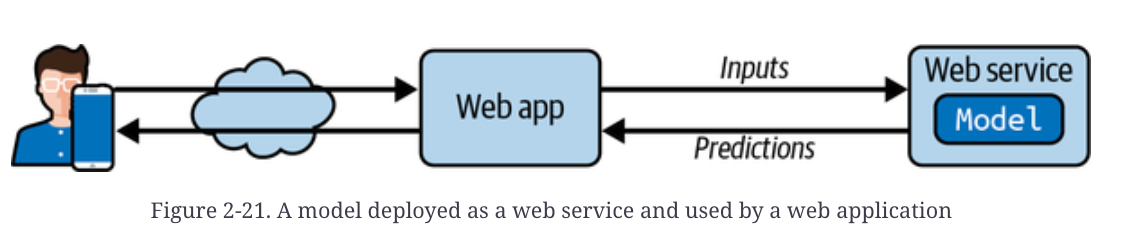

After model deployment, we need to place a monitoring system and write monitoring code to check our system's live performance at regular intervals and trigger alerts when it drops. 
- The whole process should be automated as much as possible. For instance, collect new data, train the model, and evaluate the model performance, all can be automated. 
- Also make sure to evaluate the model's input data quality.
- Make sure we keep backups of every model we created, every version of datasets we used, and have the process and tools in place to roll back to a previous model quickly.